In [28]:
import os
from pathlib import Path

project_root = "/Users/yutieyang/Documents/yuty/yuty_projects/money_game/Trading"
os.chdir(project_root)
print(Path.cwd())

/Users/yutieyang/Documents/yuty/yuty_projects/money_game/Trading


In [29]:
from freqtrade.configuration import Configuration

config = Configuration.from_files(["user_data/configs/open03/config_open03_spot.json"])
data_location = Path("/Users/yutieyang/Documents/yuty/yuty_projects/money_game/Datasets/binance/Vol_top20_202501_202506")
pair = "RAY/USDT"
config["timeframe"] = "5m"

2025-06-14 23:28:21,666 - freqtrade.configuration.load_config - INFO - Using config: user_data/configs/open03/config_open03_spot.json ...

2025-06-14 23:28:21,669 - freqtrade.configuration.load_config - INFO - Using config: trading_mode-spot.json ...

2025-06-14 23:28:21,669 - freqtrade.configuration.load_config - INFO - Using config: blacklist-binance.json ...

2025-06-14 23:28:21,670 - freqtrade.configuration.load_config - INFO - Using config: exampleconfig.json ...

2025-06-14 23:28:21,671 - freqtrade.configuration.load_config - INFO - Using config: pairlist-backtest-static-binance-spot-usdt.json ...

...

2025-06-14 23:28:21,680 - freqtrade.configuration.configuration - INFO - Using user-data directory: /Users/yutieyang/Documents/yuty/yuty_projects/money_game/Trading/user_data ...

2025-06-14 23:28:21,681 - freqtrade.configuration.configuration - INFO - Using data directory: /Users/yutieyang/Documents/yuty/yuty_projects/money_game/Trading/user_data/data/binance ...

2025-06-14 23:28:21,682 - freqtrade.exchange.check_exchange - INFO - Checking exchange...

2025-06-14 23:28:21,692 - freqtrade.exchange.check_exchange - INFO - Exchange "binance" is officially supported by the Freqtrade development team.

2025-06-14 23:28:21,694 - freqtrade.configuration.configuration - INFO - Using pairlist from configuration.

In [30]:
# Load data using values set above
from freqtrade.data.history import load_pair_history
from freqtrade.enums import CandleType

candles = load_pair_history(
    datadir=data_location,
    timeframe=config["timeframe"],
    pair=pair,
    data_format="feather",  # Make sure to update this to your data
    candle_type=CandleType.SPOT,
    # candle_type=CandleType.FUTURES,
)

# Confirm success
print(f"Loaded {len(candles)} rows of data for {pair} from {data_location}")
candles.head()

Loaded 56072 rows of data for RAY/USDT from /Users/yutieyang/Documents/yuty/yuty_projects/money_game/Datasets/binance/Vol_top20_202501_202506


,date,open,high,low,close,volume
0,2024-12-01 00:00:00+00:00,5.454,5.461,5.438,5.456,16714.6
1,2024-12-01 00:05:00+00:00,5.457,5.483,5.450,5.483,8354.7
2,2024-12-01 00:10:00+00:00,5.483,5.491,5.471,5.472,13610.7
3,2024-12-01 00:15:00+00:00,5.471,5.485,5.461,5.474,9535.4
4,2024-12-01 00:20:00+00:00,5.473,5.475,5.455,5.462,5538.4


In [32]:
from freqtrade.data.btanalysis import load_backtest_data, load_backtest_stats


# if backtest_dir points to a directory, it'll automatically load the last backtest file.
# backtest_dir = config["user_data_dir"] / "backtest_results"
# backtest_dir can also point to a specific file
# backtest_dir = (
#   config["user_data_dir"] / "backtest_results/backtest-result-2020-07-01_20-04-22.json"
# )

backtest_dir = "/Users/yutieyang/Documents/yuty/yuty_projects/money_game/Trading/user_data/backtest_results"

# You can get the full backtest statistics by using the following command.
# This contains all information used to generate the backtest result.
stats = load_backtest_stats(backtest_dir)


2025-06-14 23:30:27,297 - freqtrade.data.btanalysis - INFO - Loading backtest result from 
/Users/yutieyang/Documents/yuty/yuty_projects/money_game/Trading/user_data/backtest_results/backtest-result-2025-06-14_23-24-23.zip

In [33]:
strategy = "open03"
# All statistics are available per strategy, so if `--strategy-list` was used during backtest,
# this will be reflected here as well.
# Example usages:
print(stats["strategy"][strategy]["results_per_pair"])
# Get pairlist used for this backtest
print(stats["strategy"][strategy]["pairlist"])
# Get market change (average change of all pairs from start to end of the backtest period)
print(stats["strategy"][strategy]["market_change"])
# Maximum drawdown ()
print(stats["strategy"][strategy]["max_drawdown_abs"])
# Maximum drawdown start and end
print(stats["strategy"][strategy]["drawdown_start"])
print(stats["strategy"][strategy]["drawdown_end"])


# Get strategy comparison (only relevant if multiple strategies were compared)
print(stats["strategy_comparison"])

[{'key': 'RAY/USDT', 'trades': 13, 'profit_mean': 0.01828950534388031, 'profit_mean_pct': 1.83, 'profit_sum': 0.23776356947044408, 'profit_sum_pct': 23.78, 'profit_total_abs': 499.8368017, 'profit_total': 0.04998368017, 'profit_total_pct': 5.0, 'duration_avg': '4:40:00', 'wins': 13, 'draws': 0, 'losses': 0, 'winrate': 1.0, 'cagr': 0.11540686995001503, 'expectancy': 38.44898474615385, 'expectancy_ratio': 100.0, 'sortino': -100, 'sharpe': 2.925298118439478, 'calmar': -100, 'sqn': 6.6506, 'profit_factor': 0.0, 'max_drawdown_account': 0.0, 'max_drawdown_abs': 0.0}, {'key': 'FUN/USDT', 'trades': 4, 'profit_mean': 0.02693233511727424, 'profit_mean_pct': 2.69, 'profit_sum': 0.10772934046909696, 'profit_sum_pct': 10.77, 'profit_total_abs': 270.31173175, 'profit_total': 0.027031173175, 'profit_total_pct': 2.7, 'duration_avg': '7:21:00', 'wins': 4, 'draws': 0, 'losses': 0, 'winrate': 1.0, 'cagr': 0.06154594081846088, 'expectancy': 67.5779329375, 'expectancy_ratio': 100.0, 'sortino': -100, 'sharp

In [34]:
# Load backtested trades as dataframe
trades = load_backtest_data(backtest_dir)

# Show value-counts per pair
trades.groupby("pair")["exit_reason"].value_counts()

2025-06-14 23:30:46,416 - freqtrade.data.btanalysis - INFO - Loading backtest result from 
/Users/yutieyang/Documents/yuty/yuty_projects/money_game/Trading/user_data/backtest_results/backtest-result-2025-06-14_23-24-23.zip

pair      exit_reason                    
ADA/USDT  exit_long_rapid_rpd_3 ( 104 )      1
          exit_long_tc_d_0_101 ( 144 )       1
          exit_long_tc_d_1_58 ( 144 )        1
          exit_long_tc_d_1_71 ( 142 143 )    1
          exit_long_tc_d_2_108 ( 142 )       1
                                            ..
XRP/USDT  exit_long_tc_u_1 ( 141 )           1
          exit_long_tc_u_2 ( 141 )           1
          exit_long_tc_w_1_11 ( 144 )        1
XVG/USDT  exit_long_rebuy_d_0_52 ( 62 )      1
ZEN/USDT  exit_long_rapid_d_1_73 ( 102 )     1
Name: count, Length: 142, dtype: int64

In [35]:
# Plotting equity line (starting with 0 on day 1 and adding daily profit for each backtested day)

import pandas as pd
import plotly.express as px

from freqtrade.configuration import Configuration
from freqtrade.data.btanalysis import load_backtest_stats


# strategy = 'SampleStrategy'
# config = Configuration.from_files(["user_data/config.json"])
# backtest_dir = config["user_data_dir"] / "backtest_results"

stats = load_backtest_stats(backtest_dir)
strategy_stats = stats["strategy"][strategy]

df = pd.DataFrame(columns=["dates", "equity"], data=strategy_stats["daily_profit"])
df["equity_daily"] = df["equity"].cumsum()

fig = px.line(df, x="dates", y="equity_daily")
fig.show()

2025-06-14 23:30:52,847 - freqtrade.data.btanalysis - INFO - Loading backtest result from 
/Users/yutieyang/Documents/yuty/yuty_projects/money_game/Trading/user_data/backtest_results/backtest-result-2025-06-14_23-24-23.zip

<Axes: xlabel='date'>

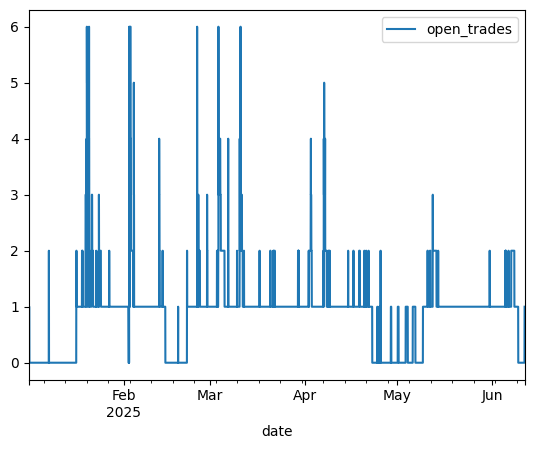

In [36]:
from freqtrade.data.btanalysis import analyze_trade_parallelism


# Analyze the above
parallel_trades = analyze_trade_parallelism(trades, "5m")

parallel_trades.plot()

In [39]:
df

,dates,equity,equity_daily
0,2025-01-01,2.165846,2.165846
1,2025-01-02,0.000000,2.165846
2,2025-01-03,0.000000,2.165846
3,2025-01-04,0.000000,2.165846
4,2025-01-05,0.000000,2.165846
...,...,...,...
157,2025-06-07,0.000000,5186.124052
158,2025-06-08,17.735640,5203.859692
159,2025-06-09,124.374690,5328.234383
160,2025-06-10,0.000000,5328.234383


In [38]:
# Report results
print(f"Generated {df['enter_long'].sum()} entry signals")
data = df.set_index("date", drop=False)
data.tail()

KeyError: 'enter_long'

In [37]:
from freqtrade.plot.plotting import generate_candlestick_graph

pair = "RAY/USDT"
# Limit graph period to keep plotly quick and reactive

# Filter trades to one pair
trades_red = trades.loc[trades["pair"] == pair]

data_red = data["2025-01-01":"2025-06-10"]
# Generate candlestick graph
graph = generate_candlestick_graph(
    pair=pair,
    data=data_red,
    trades=trades_red,
    indicators1=["sma20", "ema50", "ema55"],
    indicators2=["rsi", "macd", "macdsignal", "macdhist"],
)
# Show graph inline
# graph.show()

# Render graph in a separate window
graph.show(renderer="browser")

NameError: name 'data' is not defined